In [70]:
import math
import re
from typing import Dict, List, Optional

import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import openml as oml
import ot
import pandas as pd
from matplotlib.patches import Patch
from pennylane import numpy as pnp
from sklearn.decomposition import PCA
from ucimlrepo import fetch_ucirepo

%matplotlib inline


In [71]:
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "axes.linewidth": 0.8,
    "axes.labelsize": 11,
    "font.size": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.minor.size": 2.0,
    "ytick.minor.size": 2.0,
    "legend.fontsize": 9,
})

In [72]:
dataset_map = {
    "phishing_websites": "PW",
    "waveform_database_generator_version_1": "WDGV1",
    "pol": "Pol",
    "drybean": "DB",
    "wine_color": "WC",
    "wine": "WQ",
    "magic_gamma_telescope": "MGT",
    "electrical_grid_stability_simulated_data": "EGSSD",
}

In [73]:
df_tune_arrow = pd.read_csv("tune_arrow_combined.csv")
df_tune_err = pd.read_csv("tune_errorbar_combined.csv")
df_svm_err = pd.read_csv("svm_errorbar_combined.csv")
df_svm_logs = pd.read_csv("svm_log_retrieve.csv")

In [74]:
df_svm_logs

,dataset,num_qubit,pair,model,test_acc,source
0,wine_color,8,7,B10_Bias,0.62,svm_analysis
1,wine_color,8,7,B4_Bias,0.76,svm_analysis
2,wine_color,8,7,G3_Bias,0.88,svm_analysis
3,wine_color,8,7,B10,0.58,svm_analysis
4,wine_color,8,7,B8_Bias,0.58,svm_analysis
...,...,...,...,...,...,...
5137,ringnorm,8,6,zz_nqe,0.50,old_log
5138,ringnorm,8,7,zz_nqe,0.54,old_log
5139,ringnorm,8,8,zz_nqe,0.60,old_log
5140,ringnorm,8,9,zz_nqe,0.42,old_log


# 1. Single Dataset Errorbar

In [75]:
dataset_name = "phishing_websites"
df_arrow_k = df_tune_arrow[df_tune_arrow["dataset"].str.lower() == dataset_name].copy()
df_err_k   = df_tune_err[df_tune_err["dataset"].str.lower()   == dataset_name].copy()

def is_candidate(m):
    if not isinstance(m, str): 
        return False
    m = m.strip()
    mt = re.match(r"^([GB])(\d+)$", m)
    if not mt:
        return False
    idx = int(mt.group(2))
    return 1 <= idx <= 10

df_arrow_k = df_arrow_k[df_arrow_k["model"].apply(is_candidate)].copy()
df_err_k   = df_err_k[df_err_k["model"].apply(is_candidate)].copy()

df_arrow_k = df_arrow_k[["dataset", "qubits", "model", "init_y"]].copy()
df_err_k   = df_err_k[["dataset", "qubits", "model", "mean", "std"]].copy()

df_arrow_k.shape, df_err_k.shape

((20, 4), (20, 5))

In [76]:
df = pd.merge(
    df_arrow_k,
    df_err_k,
    on=["dataset", "qubits", "model"],
    how="inner",
    validate="one_to_one"
).copy()

df["delta_E"] = df["init_y"] - df["mean"]

df["delta_E_std"] = df["std"]

In [77]:
candidates = [f"G{i}" for i in range(1, 11)] + [f"B{i}" for i in range(1, 11)]

df["model"] = pd.Categorical(df["model"], categories=candidates, ordered=True)
df = df.sort_values("model").reset_index(drop=True)

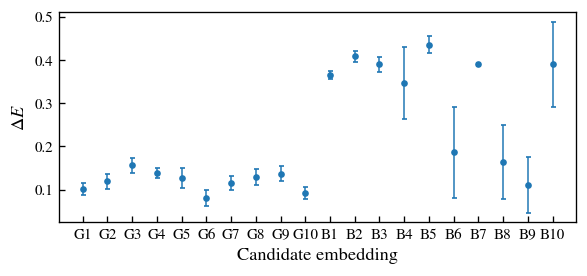

In [78]:
fig_w, fig_h = 5.0, 2.4
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

x = np.arange(len(df))
y = df["delta_E"].to_numpy()
yerr = df["delta_E_std"].to_numpy()

ax.errorbar(
    x, y, yerr=yerr,
    fmt="o", markersize=3.0,
    capsize=1.5, elinewidth=0.9
)

ax.set_xticks(x)
ax.set_xticklabels(df["model"].astype(str), ha="center")

ax.set_xlabel("Candidate embedding")
ax.set_ylabel(r"$\Delta E$")

ax.grid(False)
fig.tight_layout()

plt.show()

In [79]:
out_pdf = "fig3_delta_by_circuit.pdf"

fig.savefig(out_pdf, bbox_inches="tight")
print("saved:", out_pdf)

saved: fig3_delta_by_circuit.pdf


# 2. Multiple dataset errorbar

In [80]:
arrow = df_tune_arrow[["dataset", "qubits", "model", "init_y"]].copy()
err   = df_tune_err[["dataset", "qubits", "model", "mean", "std"]].copy()

def keep_gb_1to10(m):
    if not isinstance(m, str):
        return False
    m = m.strip()
    mt = re.match(r"^([GB])(\d+)$", m)
    if not mt:
        return False
    k = int(mt.group(2))
    return 1 <= k <= 10

arrow = arrow[arrow["model"].apply(keep_gb_1to10)].copy()
err   = err[err["model"].apply(keep_gb_1to10)].copy()

df = pd.merge(
    arrow, err,
    on=["dataset", "qubits", "model"],
    how="inner",
    validate="one_to_one"
).copy()

df["delta_E"] = df["init_y"] - df["mean"]

df["family"] = df["model"].str[0]

In [81]:
df["dataset_key"] = df["dataset"].str.lower().str.strip()

wanted_keys = list(dataset_map.keys())
df = df[df["dataset_key"].isin(wanted_keys)].copy()

df["dataset_label"] = df["dataset_key"].map(dataset_map)

dataset_order = ["PW", "WDGV1", "Pol", "DB", "WC", "WQ", "MGT", "EGSSD"]
df["dataset_label"] = pd.Categorical(df["dataset_label"], categories=dataset_order, ordered=True)


In [82]:
agg = (
    df.groupby(["dataset_label", "family"])["delta_E"]
      .agg(mean="mean", std="std", n="count")
      .reset_index()
)

agg.pivot(index="dataset_label", columns="family", values="n")


/var/folders/j2/p6vmvrcs1kg7j9c8811510sc0000gn/T/ipykernel_61269/474909701.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["dataset_label", "family"])["delta_E"]


family,B,G
dataset_label,,
PW,10,10
WDGV1,10,10
Pol,10,10
DB,10,10
WC,10,10
WQ,10,10
MGT,10,10
EGSSD,10,10


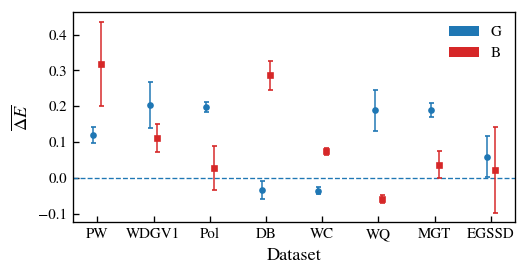

In [83]:
x_labels = dataset_order
x = np.arange(len(x_labels))

def get_series(fam):
    sub = agg[agg["family"] == fam].set_index("dataset_label").reindex(x_labels)
    y = sub["mean"].to_numpy()
    yerr = sub["std"].to_numpy()
    return y, yerr

yG, eG = get_series("G")
yB, eB = get_series("B")

dx = 0.07

fig_w, fig_h = 4.5, 2.4
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

ax.axhline(0.0, linestyle="--", linewidth=0.8)

ax.errorbar(
    x - dx, yG, yerr=eG,
    fmt="o", markersize=3.0,
    capsize=1.5, elinewidth=0.9,
    color="tab:blue", ecolor="tab:blue",
    label="G"
)

ax.errorbar(
    x + dx, yB, yerr=eB,
    fmt="s", markersize=3.0,
    capsize=1.5, elinewidth=0.9,
    color="tab:red", ecolor="tab:red",
    label="B"
)

ax.set_xticks(x)
ax.set_xticklabels(x_labels, ha="center")

ax.set_xlabel("Dataset")
ax.set_ylabel(r"$\overline{\Delta E}$")

ax.grid(False)

legend_handles = [
    Patch(facecolor="tab:blue", edgecolor="none", label="G"),
    Patch(facecolor="tab:red",  edgecolor="none", label="B"),
]
ax.legend(handles=legend_handles, frameon=False, loc="upper right")

fig.tight_layout()
plt.show()


In [84]:
out_pdf = "fig4_delta_by_dataset.pdf"

fig.savefig(out_pdf, bbox_inches="tight")
print("saved:", out_pdf)

saved: fig4_delta_by_dataset.pdf


# 3. Winning Summary

In [85]:
datasets = [
    'phishing_websites',
    'waveform_database_generator_version_1',
    'pol',
    'drybean',
    'wine_color',
    'wine',
    'magic_gamma_telescope',
    'electrical_grid_stability_simulated_data',
    ]

In [86]:
def compute_winning_summary(
    df: pd.DataFrame,
    dataset: str,
    base_model: str = "classical",
    max_pairs: int = 10,
) -> Dict:
    sub = df[(df["dataset"] == dataset) & (df["pair"] <= max_pairs)].copy()
    if sub.empty:
        raise ValueError(f"No rows for dataset='{dataset}' in df")

    pivot = sub.pivot_table(
        index="pair", columns="model", values="test_acc", aggfunc="mean"
    )

    base = pivot[base_model]

    def _summary_vs(label: str) -> Optional[Dict]:
        if label not in pivot.columns:
            return None

        other = pivot[label]
        mask = base.notna() & other.notna()
        if not mask.any():
            return None

        diff = base[mask] - other[mask]

        base_wins = int((diff > 0).sum())
        ties = int((diff == 0).sum())
        opponent_wins = int((diff < 0).sum())
        total = base_wins + ties + opponent_wins

        return {
            "label": label,
            "base_wins": base_wins,
            "ties": ties,
            "opponent_wins": opponent_wins,
            "total": total,
        }

    all_models = [m for m in pivot.columns if m != base_model]

    groups = {
        "G": [m for m in all_models if re.fullmatch(r"G\d+", m)],
        "G_Bias": [m for m in all_models if re.fullmatch(r"G\d+_Bias", m)],
        "B": [m for m in all_models if re.fullmatch(r"B\d+", m)],
        "B_Bias": [m for m in all_models if re.fullmatch(r"B\d+_Bias", m)],
    }

    opponents: List[Dict] = []

    for group_name, labels in groups.items():
        candidates = []
        for lbl in labels:
            s = _summary_vs(lbl)
            if s is not None:
                candidates.append(s)
        if not candidates:
            continue

        def key_fn(s):
            opp_win_rate = s["opponent_wins"] / s["total"] if s["total"] > 0 else 0.0
            return (s["opponent_wins"], opp_win_rate, s["label"])

        best = max(candidates, key=key_fn)
        best["group"] = group_name
        opponents.append(best)

    for group_name, lbl in [("ZZ_NQE", "zz_nqe"), ("ZZ", "zz")]:
        s = _summary_vs(lbl)
        if s is not None:
            s["group"] = group_name
            opponents.append(s)

    desired_order = ["G", "G_Bias", "B", "B_Bias", "ZZ_NQE", "ZZ"]
    opp_by_group = {o["group"]: o for o in opponents}
    ordered = []
    for g in desired_order:
        if g in opp_by_group:
            ordered.append(opp_by_group[g])

    return {
        "dataset": dataset,
        "base_model": base_model,
        "max_pairs": max_pairs,
        "opponents": ordered,
    }

In [113]:
def plot_winning_summary(
    summary: Dict,
    ax: Optional[plt.Axes] = None,
    show_actual_labels: bool = False,
):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    else:
        fig = ax.figure

    opponents = summary["opponents"]
    order = {
        "G": 0,
        "G_Bias": 1,
        "B": 2,
        "B_Bias": 3,
        "ZZ_NQE": 4,
        "ZZ": 5,
    }
    opponents = sorted(summary["opponents"], key=lambda o: order.get(o["group"], 999))
    max_pairs = summary["max_pairs"]
    dataset = summary["dataset"]
    base_model = summary["base_model"]

    if not opponents:
        ax.set_title(f"{dataset}: no opponents found")
        return ax

    x = np.arange(len(opponents)) * 2
    group_labels = []
    actual_labels = []

    for o in opponents:
        g = o["group"]
        if g == "G":
            gl = r"$\mathregular{G^{*}}$"
        elif g == "G_Bias":
            gl = r"$\mathregular{G^{*}(Bias)}$"
        elif g == "B":
            gl = r"$\mathregular{B^{*}}$"
        elif g == "B_Bias":
            gl = r"$\mathregular{B^{*}(Bias)}$"
        elif g == "ZZ_NQE":
            gl = r"$\mathregular{NQE}$"
        elif g == "ZZ":
            gl = r"$\mathregular{ZZ}$"
        else:
            gl = f"{g}"
        group_labels.append(gl)
        actual_labels.append(o["label"])

    opp_wins = np.array([o["opponent_wins"] for o in opponents])
    ties = np.array([o["ties"] for o in opponents])
    opp_losses = np.array([o["base_wins"] for o in opponents])

    ax.bar(x, opp_wins, color="steelblue", label="Win")
    ax.bar(x, ties, bottom=opp_wins, color="khaki", label="Tie")
    ax.bar(x, opp_losses, bottom=opp_wins + ties, color="lightcoral", label="Lose")

    ax.set_ylim(0, max_pairs)
    ax.set_ylabel("Splits", fontsize=12)

    
    if base_model.lower() == "classical":
        base_name = "Classical"
    ax.set_title(dataset_map.get(dataset, dataset))

    if show_actual_labels:
        xticks = [f"{g}\n({lbl})" for g, lbl in zip(group_labels, actual_labels)]
    else:
        xticks = group_labels

    ax.set_xticks(x)
    ax.set_xticklabels(xticks, fontsize=11)
    ax.margins(x=0.1)

    ax.set_ylabel("Splits", fontsize=14)
    ax.set_title(dataset_map.get(dataset, dataset), fontsize=14)
    ax.tick_params(axis="both", labelsize=12)
    ax.set_xticklabels(xticks, fontsize=12.3)

    return ax

In [114]:
def save_winning_plots(
    df: pd.DataFrame,
    datasets: List[str],
    base_model: str = "classical",
    max_pairs: int = 10,
    mode: str = "separate",
    ncols: int = 4,
    show_actual_labels: bool = False,
    save = False,
):

    summaries = []
    for ds in datasets:
        s = compute_winning_summary(
            df, dataset=ds, base_model=base_model, max_pairs=max_pairs
        )
        summaries.append(s)

    if mode == "separate":
        for s in summaries:
            fig, ax = plt.subplots(figsize=(6, 4))
            plot_winning_summary(s, ax=ax, show_actual_labels=show_actual_labels)
            fname = f"win_summary_{s['dataset']}.pdf"
            fig.tight_layout()
            if save:
                fig.savefig(fname, dpi=600, bbox_inches="tight")
                print(f"Saved: {fname}")
            else:
                plt.show()
            plt.close(fig)
        return

    if mode == "combined":
        n = len(summaries)
        ncols = max(1, ncols)
        nrows = math.ceil(n / ncols)

        fig, axes = plt.subplots(
            nrows=nrows, ncols=ncols, figsize=(4 * ncols, 2 * nrows), squeeze=True
        )

        for idx, s in enumerate(summaries):
            r = idx // ncols
            c = idx % ncols
            ax = axes[r][c]
            plot_winning_summary(s, ax=ax, show_actual_labels=show_actual_labels)

        for idx in range(len(summaries), nrows * ncols):
            r = idx // ncols
            c = idx % ncols
            fig.delaxes(axes[r][c])

        if base_model.lower() == "classical":
            base_name = "Classical"

        handles, labels = ax.get_legend_handles_labels()

        fig.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.995),
            ncol=3,
            fontsize=15,
        )

        fig.tight_layout(rect=[0, 0.0, 1, 0.94])

        if save:
            fig.savefig("fig5_winning_summary.pdf", dpi=600, bbox_inches="tight")
            print("Saved: fig5_winning_summary.pdf")
        else:
            plt.show()
        plt.close(fig)
        return

    raise ValueError(f"Unknown mode='{mode}'. Use 'separate' or 'combined'.")

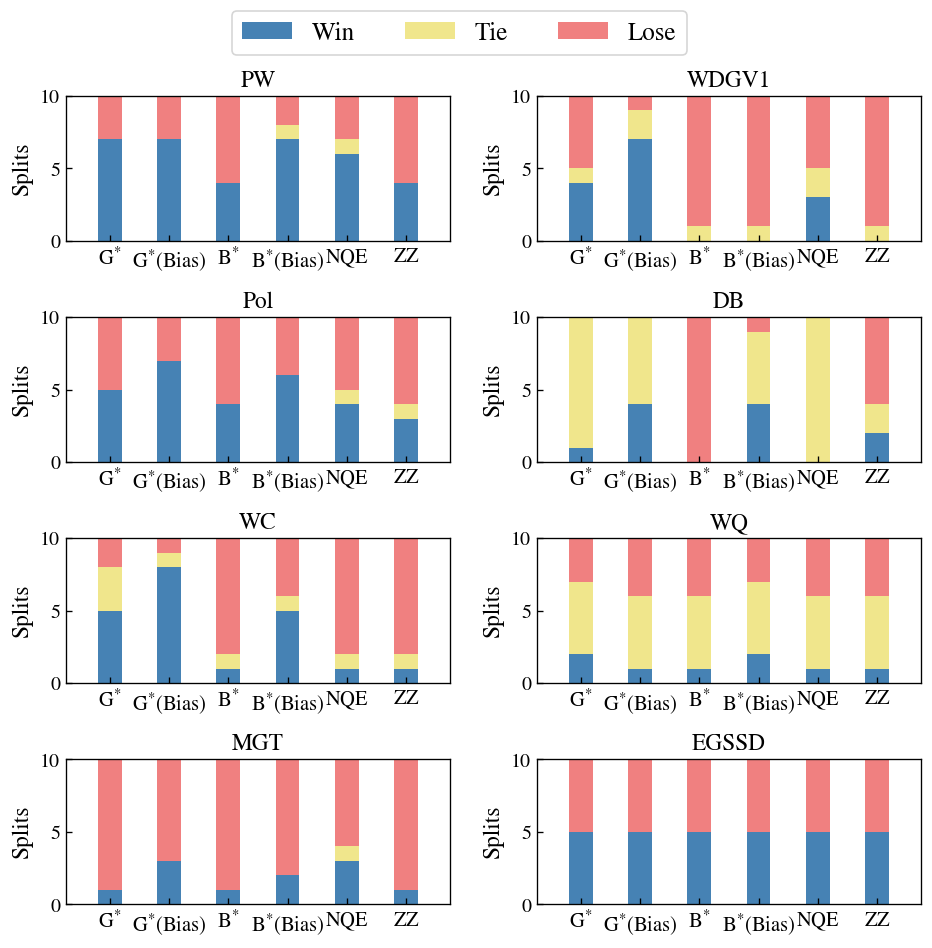

In [115]:
save_winning_plots(
    df_svm_logs,
    datasets=datasets,
    base_model="classical",
    max_pairs=10,
    mode="combined",
    ncols = 2,
    show_actual_labels=False,
)

In [116]:
save_winning_plots(
    df_svm_logs,
    datasets=datasets,
    base_model="classical",
    max_pairs=10,
    mode="combined",
    ncols = 2,
    show_actual_labels=False,
    save=True
)

Saved: fig5_winning_summary.pdf


# 4. Dispersion

In [91]:
df_tmp = df_svm_err.copy()

In [92]:
def map_dataset(s):
    k = str(s).lower().strip()
    if k in dataset_map:
        return dataset_map[k]
    s2 = str(s).strip()
    if s2 in set(dataset_map.values()):
        return s2
    return None

In [93]:
df_tmp["dataset_label"] = df_tmp["dataset"].apply(map_dataset)
df_tmp = df_tmp[df_tmp["dataset_label"].notna()].copy()

In [94]:
def norm_model(m):
    s = str(m).strip()
    sl = s.lower()

    if sl == "classical":
        return "Classical"
    if sl in ["classical_rbf", "rbf_svm", "rbf"]:
        return "Classical_RBF"
    if sl in ["zz", "zz_featuremap", "zz_feature_map"]:
        return "ZZ"
    if sl in ["zz_nqe", "zznqe", "zz-nqe"]:
        return "ZZ_NQE"

    mt = re.match(r"^([BG])(\d+)(?:_Bias)?$", s, flags=re.IGNORECASE)
    if mt:
        fam = mt.group(1).upper()
        idx = int(mt.group(2))
        if not (1 <= idx <= 10):
            return None
        if "_bias" in sl:
            return f"{fam}_Bias{idx:02d}"
        else:
            return f"{fam}{idx:02d}"

    return None


In [95]:
df_tmp["model_norm"] = df_tmp["model"].apply(norm_model)
df_tmp = df_tmp[df_tmp["model_norm"].notna()].copy()

In [96]:
def aggregate_mean_std(sub):
    mu = sub["test_mean"].to_numpy(float)
    sd = sub["test_std"].to_numpy(float)
    mean_mu = float(np.mean(mu))
    within = float(np.mean(sd**2)) if len(sd) else np.nan
    between = float(np.var(mu, ddof=1)) if len(mu) > 1 else 0.0
    agg_std = float(np.sqrt(within + between))
    return pd.Series({"mean": mean_mu, "std": agg_std, "n": len(mu)})

In [97]:
agg = (
    df_tmp.groupby(["dataset_label", "model_norm"], observed=True)
      .apply(aggregate_mean_std)
      .reset_index()
)

/var/folders/j2/p6vmvrcs1kg7j9c8811510sc0000gn/T/ipykernel_61269/3257041251.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregate_mean_std)


In [98]:
def dispersion_std_of_means(sub):
    mus = sub["mean"].to_numpy(float)
    mus = mus[np.isfinite(mus)]
    return float(np.std(mus, ddof=1)) if mus.size >= 2 else np.nan

def dispersion_total(sub):
    mus = sub["mean"].to_numpy(float)
    sds = sub["std"].to_numpy(float)
    mask = np.isfinite(mus) & np.isfinite(sds)
    mus, sds = mus[mask], sds[mask]
    if mus.size < 2:
        return np.nan
    between = float(np.var(mus, ddof=1))
    within = float(np.mean(sds**2))
    return float(np.sqrt(between + within))

def dispersion_iqr_of_means(sub):
    mus = sub["mean"].to_numpy(float)
    mus = mus[np.isfinite(mus)]
    if mus.size < 2:
        return np.nan
    q25, q75 = np.quantile(mus, [0.25, 0.75])
    return float(q75 - q25)

In [ ]:
use_models = (
    ["ZZ", "ZZ_NQE"]
    + [f"G{i:02d}" for i in range(1, 11)]
    + [f"G_Bias{i:02d}" for i in range(1, 11)]
    + [f"B{i:02d}" for i in range(1, 11)]
    + [f"B_Bias{i:02d}" for i in range(1, 11)]
)

disp_rows = []
for d in dataset_map.values():
    sub = agg[agg["dataset_label"] == d].copy()
    if use_models is not None:
        sub = sub[sub["model_norm"].isin(use_models)]

    disp_rows.append({
        "dataset": d,
        "iqr_means": dispersion_iqr_of_means(sub),
        "n_models": int(sub["model_norm"].nunique())
    })

disp_df = pd.DataFrame(disp_rows)

disp_rows = []
for d in dataset_map.values():
    sub = agg[agg["dataset_label"] == d].copy()
    if use_models is not None:
        sub = sub[sub["model_norm"].isin(use_models)]

    disp_rows.append({
        "dataset": d,
        "iqr_means": dispersion_iqr_of_means(sub),
        "n_models": int(sub["model_norm"].nunique())
    })

disp_df = pd.DataFrame(disp_rows)

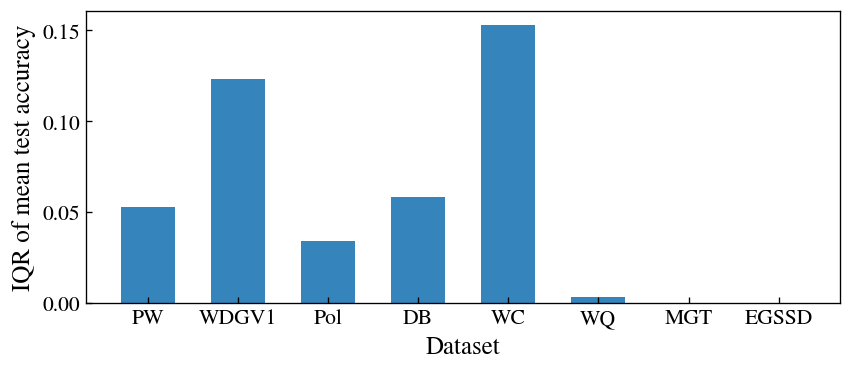

In [100]:
x = np.arange(len(datasets))
y = disp_df["iqr_means"].to_numpy()

fig, ax = plt.subplots(figsize=(7.2, 3.2))
ax.bar(x, y, width=0.6, alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(dataset_map.values(), fontsize=11)
ax.set_xlabel("Dataset", fontsize=12)
ax.set_ylabel("IQR of model mean test accuracy", fontsize=12)


ax.set_xticklabels(dataset_map.values(), fontsize=14)
ax.set_xlabel("Dataset", fontsize=15)
ax.set_ylabel("IQR of mean test accuracy", fontsize=15)
ax.tick_params(axis="both", labelsize=13)

ax.grid(False)
fig.tight_layout()
plt.show()

In [101]:
out_pdf = "fig6_dispersion.pdf"

fig.savefig(out_pdf, bbox_inches="tight")
print("saved:", out_pdf)

saved: fig6_dispersion.pdf


# 5. Heatmap

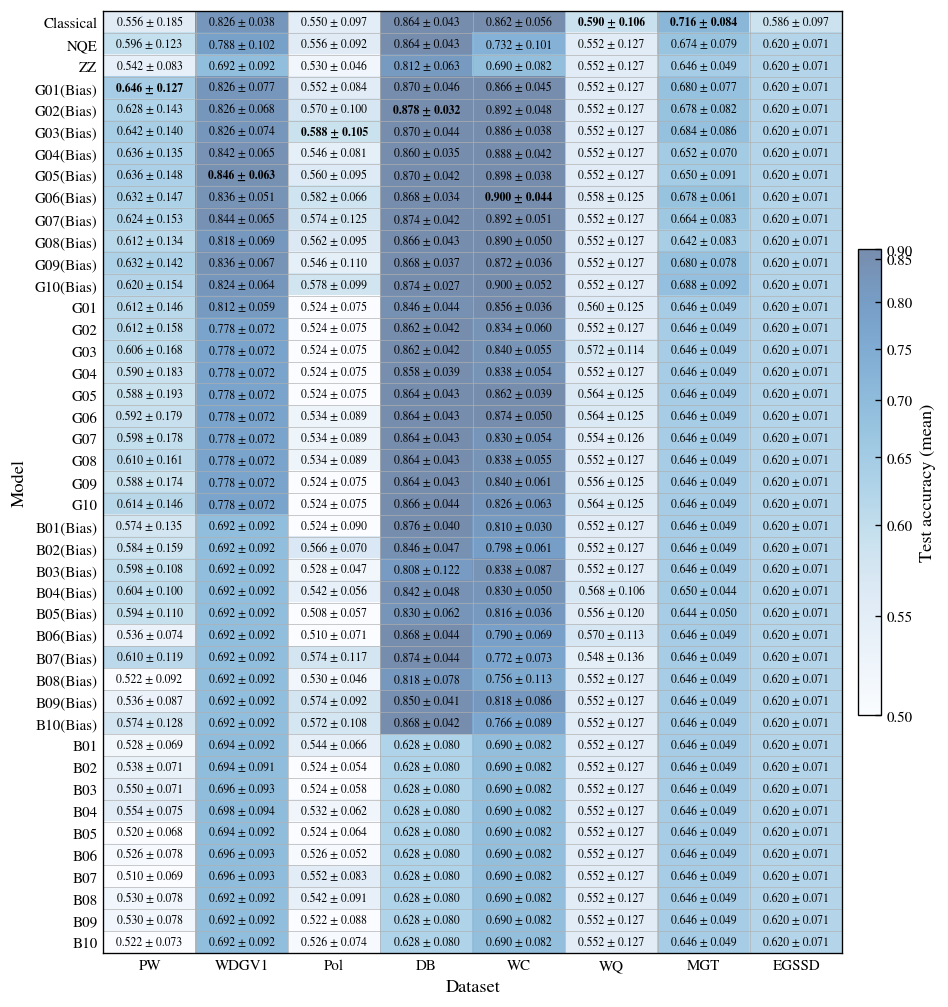

In [376]:
df_svm = df_svm_logs.copy()

agg = (
    df_svm
    .groupby(["dataset", "model"])["test_acc"]
    .agg(test_mean="mean", test_std="std")
    .reset_index()
)

def map_dataset(s):
    k = str(s).lower().strip()
    if k in dataset_map:
        return dataset_map[k]
    if str(s) in dataset_map.values():
        return str(s)
    return None

agg["dataset_label"] = agg["dataset"].apply(map_dataset)
agg = agg[agg["dataset_label"].notna()].copy()

dataset_order = [
     "PW", 
     "WDGV1", 
     "Pol", 
     "DB",
     "WC",  
     "WQ", 
     "MGT", 
     "EGSSD"
     ]
 
agg["dataset_label"] = pd.Categorical(
    agg["dataset_label"],
    categories=dataset_order,
    ordered=True
)

def normalize_model(m):
    s = str(m).strip()
    sl = s.lower()

    if sl == "classical":
        return "Classical_Linear"
    if sl in ["classical_rbf", "rbf_svm", "rbf"]:
        return "Classical_RBF"
    if sl in ["zz", "zz_featuremap", "zz_feature_map"]:
        return "ZZ"
    if sl in ["zz_nqe", "zznqe", "zz-nqe"]:
        return "ZZ_NQE"

    mt = re.match(r"^([BG])(\d+)(?:_Bias)?$", s, flags=re.IGNORECASE)
    if mt:
        fam = mt.group(1).upper()
        idx = int(mt.group(2))
        if not (1 <= idx <= 10):
            return None
        if "_bias" in sl:
            return f"{fam}_Bias{idx:02d}"
        else:
            return f"{fam}{idx:02d}"

    return None

agg["model_norm"] = agg["model"].apply(normalize_model)
agg = agg[agg["model_norm"].notna()].copy()


model_order = (
    ["Classical_Linear", "Classical_RBF", "ZZ_NQE", "ZZ"]
    + [f"G_Bias{i:02d}" for i in range(1, 11)]
    + [f"G{i:02d}" for i in range(1, 11)]
    + [f"B_Bias{i:02d}" for i in range(1, 11)]
    + [f"B{i:02d}" for i in range(1, 11)]
)

agg["model_norm"] = pd.Categorical(
    agg["model_norm"],
    categories=model_order,
    ordered=True
)
agg = agg.sort_values(["model_norm", "dataset_label"]).copy()

mean_mat = (
    agg.pivot(index="model_norm", columns="dataset_label", values="test_mean")
       .reindex(index=model_order, columns=dataset_order)
)

std_mat = (
    agg.pivot(index="model_norm", columns="dataset_label", values="test_std")
       .reindex(index=model_order, columns=dataset_order)
)

M = mean_mat.to_numpy()
S = std_mat.to_numpy()

fig_w, fig_h = 8.0, 8.5
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

vals = M[np.isfinite(M)]
if vals.size:
    vmin = np.quantile(vals, 0.05)
    vmax = np.quantile(vals, 0.9)
else:
    vmin, vmax = (None, None)

norm = mcolors.PowerNorm(
    gamma=0.6,
    vmin=vmin,
    vmax=vmax,
    clip=True
)

im = ax.imshow(
    M,
    aspect="auto",
    cmap="Blues",
    norm=norm,
    alpha=0.55
)

def format_model_label(m):
    if m == "Classical_Linear":
        return "Classical(Linear)"
    if m == "Classical_RBF":
        return "Classical(RBF)"
    if m == "ZZ_NQE":
        return "NQE"
    if m == "ZZ":
        return "ZZ"
    if m == "Classical":
        return "Classical"

    mt = re.match(r"^([GB])_Bias(\d+)$", str(m))
    if mt:
        fam = mt.group(1)
        idx = mt.group(2)
        return f"{fam}{idx}(Bias)"

    mt = re.match(r"^([GB])(\d+)$", str(m))
    if mt:
        fam = mt.group(1)
        idx = mt.group(2)
        return f"{fam}{idx}"

    return str(m)

display_model_labels = [format_model_label(m) for m in model_order]

ax.set_xticks(np.arange(len(dataset_order)))
ax.set_xticklabels(dataset_order)
ax.set_yticks(np.arange(len(model_order)))
display_model_labels = ["NQE" if m == "ZZ_NQE" else m for m in display_model_labels]

ax.set_xticks(np.arange(len(dataset_order)))
ax.set_xticklabels(dataset_order)
ax.set_yticks(np.arange(len(model_order)))
ax.set_yticklabels(display_model_labels)

ax.set_xlabel("Dataset")
ax.set_ylabel("Model")
ax.tick_params(axis="both", which="both", length=0)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Test accuracy (mean)")

for i in range(len(model_order)):
    for j in range(len(dataset_order)):
        if np.isfinite(M[i, j]) and np.isfinite(S[i, j]):
            txt = f"{M[i,j]:.3f} ± {S[i,j]:.3f}"

            dataset_name = dataset_order[j]

            if dataset_name != "EGSSD":
                col_vals = M[:, j]
                if np.any(np.isfinite(col_vals)):
                    best_i = np.nanargmax(col_vals)
                    is_best = (i == best_i)
                else:
                    is_best = False
            else:
                is_best = False

            ax.text(
                j, i, txt,
                ha="center", va="center",
                fontsize=7,
                fontweight="bold" if is_best else "normal"
            )

ax.set_xticks(np.arange(-.5, len(dataset_order), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(model_order), 1), minor=True)
ax.grid(which="minor", linestyle="-", linewidth=0.4)
ax.tick_params(which="minor", bottom=False, left=False, length=0)

fig.tight_layout()
plt.show()

In [377]:
out_pdf = "fig7_total_heatmap.pdf"

fig.savefig(out_pdf, bbox_inches="tight")
print("saved:", out_pdf)

saved: fig7_total_heatmap.pdf


# Wasserstein

In [380]:
def _data_getter(data_name):
    uci_id = {
        "magic_gamma_telescope": 159,
        "phishing_websites": 327,
        "electrical_grid_stability": 471,
        "electrical_grid_stability_simulated_data": 471,
        "drybean": 602,
        "wine": 186,
        "wine_color": 186,
        "waveform_database_generator_version_1":107,
    }

    oml_id = {
        "pol":44122,
    }

    data_registry = {**{k: ("uci", v) for k, v in uci_id.items()}, **{k: ("oml", v) for k, v in oml_id.items()}}

    key = str(data_name).strip()
    try:
        source, did = data_registry[key]
    except KeyError:
        raise ValueError(f"Unsupported data_name: {data_name}")

    if source == "uci":
        data = fetch_ucirepo(id=did)
        if key == "wine_color":
            data.data.targets = data.data.original[["color"]]

    if source == "oml":
        data = oml.datasets.get_dataset(did)

    return data, source


def data_load_and_process(dataset, reduction_sz, train_len, test_len, slice_start=0):
    data, source = _data_getter(dataset)

    if source == "oml":
        X, y, _, _ = data.get_data(dataset_format="dataframe", target=data.default_target_attribute,)

    if source == "uci":
        X, y = data.data.features, data.data.targets


    if dataset == "magic_gamma_telescope":
        shuffled = X.join(y).sample(frac=1, random_state=42).reset_index(drop=True)
        X = shuffled[X.columns]
        y = shuffled[y.columns]
    if dataset == "electrical_grid_stability" or dataset == "electrical_grid_stability_simulated_data":
        y = y['stabf']
    if dataset == "drybean":
        y.reset_index(drop=True, inplace=True)
        X.reset_index(drop=True, inplace=True)
        select = y.index[y['Class'].isin(['DERMASON', 'SIRA'])]
        X = X.loc[select]
        y = y.loc[select]

        shuffled = X.join(y).sample(frac=1, random_state=42).reset_index(drop=True)
        X = shuffled[X.columns]
        y = shuffled[y.columns]
    if dataset == "pol":
        y = y.to_frame()
        shuffled = X.join(y).sample(frac=1, random_state=42).reset_index(drop=True)
        X = shuffled[X.columns]
        y = shuffled[y.columns]
    if dataset == "wine":
        y.reset_index(drop=True, inplace=True)
        X.reset_index(drop=True, inplace=True)
        select = y.index[y['quality'].isin([6, 5])]
        X = X.loc[select]
        y = y.loc[select]
    if dataset == "wine_color":
        X = X[:5001]
        y = y[:5001]
        shuffled = X.join(y).sample(frac=1, random_state=42).reset_index(drop=True)
        X = shuffled[X.columns]
        y = shuffled[y.columns]

    X = X.to_numpy(dtype=float)
    y = y.to_numpy().ravel()

    uniq = pnp.unique(y)
    y = pnp.where(y == uniq[0], 0, 1)

    assert len(pnp.unique(y)) == 2, f"Expected 2 unique, but got {pnp.unique(y)}"

    x_tr, x_te = X[slice_start:slice_start + train_len], X[slice_start + train_len:slice_start + train_len + test_len]
    y_tr, y_te = y[slice_start:slice_start + train_len], y[slice_start + train_len:slice_start + train_len + test_len]

    X_train = PCA(reduction_sz).fit_transform(x_tr)
    X_test = PCA(reduction_sz).fit_transform(x_te)

    def normalize_to_2pi(arr):
        arr_normed = []
        for x in arr:
            x = (x - x.min()) * (2 * pnp.pi / (x.max() - x.min()))
            arr_normed.append(x)
        return pnp.array(arr_normed)

    X_train = normalize_to_2pi(X_train)
    X_test = normalize_to_2pi(X_test)

    return X_train, X_test, y_tr, y_te

In [381]:
def _cost_matrix(X0, X1, squared=False):
    diff = X0[:, None, :] - X1[None, :, :]
    if squared:
        return np.sum(diff ** 2, axis=2)
    else:
        return np.linalg.norm(diff, axis=2)


def wasserstein_dist_OT(X, y):
    X0 = X[y == 0]
    X1 = X[y == 1]

    n0, n1 = X0.shape[0], X1.shape[0]
    a = np.ones(n0) / n0
    b = np.ones(n1) / n1

    C = _cost_matrix(X0, X1, squared=False)  # Euclidean distance

    W1 = ot.emd2(a, b, C)
    return W1

In [383]:
for dataset in dataset_map.keys():

    X_train, X_test, y_tr, y_te = data_load_and_process(dataset, 8, 1000, 20)
    print(f"{dataset}: {wasserstein_dist_OT(X_train, y_tr)}")

phishing_websites: 5.237986079631781
waveform_database_generator_version_1: 5.156909718876581
pol: 4.354252136104729
drybean: 13.910770782775261
wine_color: 10.856213530945377
wine: 3.011228265601372
magic_gamma_telescope: 3.3035639516071
electrical_grid_stability_simulated_data: 3.5617802600014703
